<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFFF; max-width: 90%; overflow-x: auto; color: #000000;">

<img src="../../resources/swdb_logo.jpg">

<h1 align="center">Mini-Workshop 3: You Must Cross-Validate Sorted Plots</h1>
<h3 align="center">Summer Workshop on the Dynamic Brain</h3>
<h4 align="center">Thursday, August 27th, 2026</h4>
<h4 align="center">Day 4</h4>

---

***Authors:** Nick Steinmetz, Carrie Stine*

---

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

# The Setup: 
A colleague recorded 100 neurons over a 2-second interval (10 trials each),
trial-averaged the data, sorted the neurons by their peak activity time, and
produced a figure showing a crisp diagonal sweep - every neuron firing at its
own characteristic moment, one after another.

Run the cells to reproduce the analysis, then work through the exercise to
evaluate whether the sequence is real.
</div>

In [1]:
# Setup (imports and plotting defaults)
import os
from pathlib import Path

if '__vsc_ipynb_file__' in dir():
    os.chdir(Path(__vsc_ipynb_file__).parent)
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import spearmanr

plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['font.sans-serif']   = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42
SMOOTH_SIGMA = 3.0   # temporal smoothing (bins)

def smooth(x):
    """Smooth each row of x with a Gaussian kernel along the time axis."""
    return gaussian_filter1d(x, SMOOTH_SIGMA, axis=1)

def zscore_rows(m):
    """Z-score each row independently (subtract mean, divide by std)."""
    return (m - m.mean(1, keepdims=True)) / (m.std(1, keepdims=True) + 1e-9)

def show_seq(ax, mat, time, cmap='viridis', title=''):
    """Display a neurons x time matrix, z-scored row-wise."""
    n  = mat.shape[0]
    im = ax.imshow(zscore_rows(mat), aspect='auto', cmap=cmap,
                   extent=[time[0], time[-1], n, 0])
    ax.set_xlabel('time (s)'); ax.set_ylabel('neuron'); ax.set_title(title)
    return im


In [2]:
# Load the dataset: (neuron, time, trial) array.
d         = np.load('data/activity.npz')
activity  = d['activity']           # (n_neurons, n_time, n_trials)
time      = d['time']
dt        = float(d['dt'])
n_neurons, n_time, n_trials = activity.shape
print(f'{n_neurons} neurons x {n_time} time bins x {n_trials} trials '
      f'({time[0]:.2f}-{time[-1]:.2f} s)')


100 neurons x 100 time bins x 10 trials (0.00-1.98 s)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

## The analysis: trial-average, smooth, sort, and display

The standard approach for detecting a neural sequence:

1. Average neural activity across all trials to reduce noise.
2. Smooth each neuron's trace along time.
3. Find each neuron's **peak time** (the time bin with the highest activity).
4. Sort neurons from earliest to latest peak time and display as a heatmap.

</div>


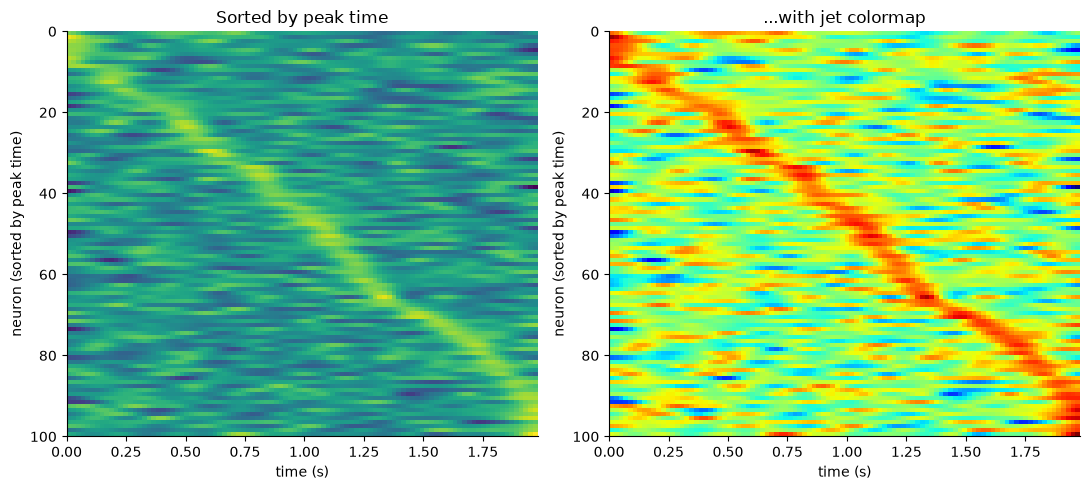

In [3]:
# Trial-average and smooth - reduces noise for visualization.
X = smooth(activity.mean(axis=2))     # (n_neurons, n_time)

# Sort neurons by their peak activity time (earliest to latest).
peak_bin = X.argmax(axis=1)           # time bin of peak for each neuron
order    = np.argsort(peak_bin)       # sort order: earliest to latest

# Display the sorted population matrix.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
show_seq(axes[0], X[order], time, cmap='viridis', title='Sorted by peak time')
show_seq(axes[1], X[order], time, cmap='jet',     title='...with jet colormap')
for ax in axes:
    ax.set_ylabel('neuron (sorted by peak time)')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

The sorted heatmap shows a crisp diagonal sweep. A colleague concludes:

> *"These neurons are activated in a reliable, stereotyped temporal sequence
> that tiles the whole interval - each neuron fires at its own characteristic
> moment, one after another."*

**The claim is not supported by this analysis.** Your job is to work out why.

</div>


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8; max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Evaluate the neural sequence

Can you figure out why the conclusion is not supported? 

**Please spend at least the first 15 minutes working as a group without opening the hints or solutions.** Talk through what you think the code should do, sketch out an approach, and try writing it yourself, even if it's imperfect!

After 15 minutes if your group still feels genuinely stuck, you're welcome to reveal the hints below, or check the solutions notebook if needed.

---

<details>
<summary><b>Conceptual Hint 1</b></summary>

 **_Is each neuron's peak time consistent across independent data?_** Does the 'sequence' look the same when the sort order is applied to data that was not used to generate the sort?

 <details>
 <summary><b>Coding Hint 1</b></summary>

 *Design a cross-validation check. Split the trials into two halves (try <code>odd = activity[:, :, 0::2]</code> and <code>even = activity[:, :, 1::2]</code>). Sort the neurons by their peak time on one half of trials, then display the other half in that order.*

 </details>

</details>

---

<details>
<summary><b>Conceptual Hint 2</b></summary>

 A 'sequence' is a claim that each neuron fires at a characteristic time. **_How could you check whether a neuron's peak time is reproducible?_** 

 <details>
 <summary><b>Coding Hint 2</b></summary>

 *Estimate each neuron's peak time on one half of trials, and again on the other half independently. Use `scipy.stats.spearmanr` to compute the rank correlation between peak times estimated from the two independent trial halves. What do you expect to see if the sequence is real?*

 </details>

</details>

---

<details>
<summary><b>Conceptual Hint 3</b></summary>

 The sort order was computed from the data being displayed. **_What if you sorted a matrix of pure random numbers by each row's peak column?_** 

 <details>
 <summary><b>Coding Hint 3</b></summary>

 *Generate a new random matrix of the same shape as `X` (using `rng.normal`), apply `smooth()`, sort rows by peak time, and display the result.*
 
 </details>

</details>

---



</div>


## Solution


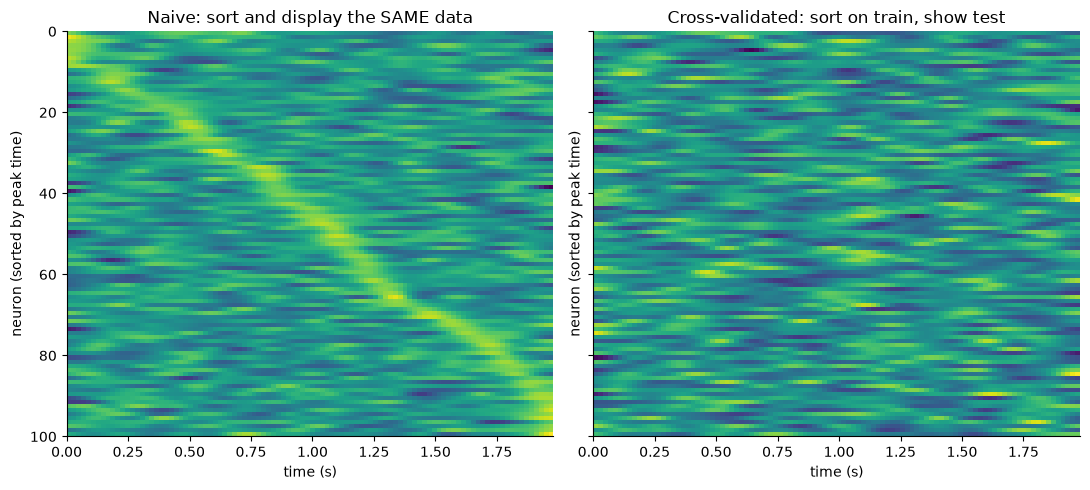

In [4]:
# ── Evidence 1: Cross-validate the sort ──────────────────────────────────
# Sort neurons using peak times estimated from ODD trials,
# then display EVEN trials in that order.
# A real sequence survives; a sorting artifact collapses to noise.
train = smooth(activity[:, :, 0::2].mean(axis=2))   # odd trials: derive sort order from these
test  = smooth(activity[:, :, 1::2].mean(axis=2))   # even trials: display these

order_train = np.argsort(train.argmax(axis=1))       # sort order from train only

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
show_seq(axes[0], X[order], time,
         title='Naive: sort and display the SAME data')
show_seq(axes[1], test[order_train], time,
         title='Cross-validated: sort on train, show test')
for ax in axes:
    ax.set_ylabel('neuron (sorted by peak time)')
plt.tight_layout()
plt.show()


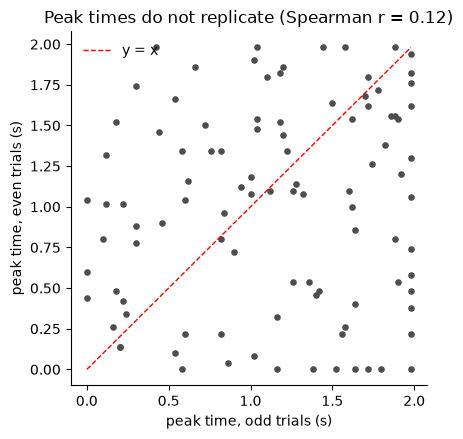

Spearman rank correlation of peak times across independent halves: 0.124
(A real sequence would give r near 1.)


In [5]:
# ── Evidence 2: Check if peak times are reproducible across trials ─────────────
# If each neuron truly fired at a characteristic time, its peak estimated
# from one half of trials would predict its peak from the other half.
pa  = train.argmax(1) * dt    # peak time (s) from odd trials
pb  = test.argmax(1)  * dt    # peak time (s) from even trials (independent)
rho = spearmanr(pa, pb).correlation

fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.scatter(pa, pb, s=14, color='0.3')
ax.plot([time[0], time[-1]], [time[0], time[-1]], 'r--', lw=1, label='y = x')
ax.set_xlabel('peak time, odd trials (s)')
ax.set_ylabel('peak time, even trials (s)')
ax.set_title(f'Peak times do not replicate (Spearman r = {rho:.2f})')
ax.legend(frameon=False)
plt.show()
print(f'Spearman rank correlation of peak times across independent halves: {rho:.3f}')
print('(A real sequence would give r near 1.)')


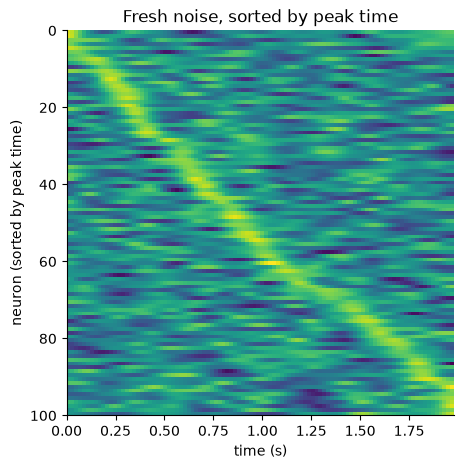

In [6]:
# ── Evidence 3: Sorting any noise produces the same diagonal ──────────────
# Generate a fresh, independent noise matrix and apply the identical pipeline.
# The diagonal is a property of peak-sorting, not of these particular neurons.
rng         = np.random.default_rng(0)
fresh       = smooth(rng.normal(0, 1, size=(n_neurons, n_time)))
fresh_order = np.argsort(fresh.argmax(1))

fig, ax = plt.subplots(figsize=(5, 5))
show_seq(ax, fresh[fresh_order], time, title='Fresh noise, sorted by peak time')
ax.set_ylabel('neuron (sorted by peak time)')
plt.show()


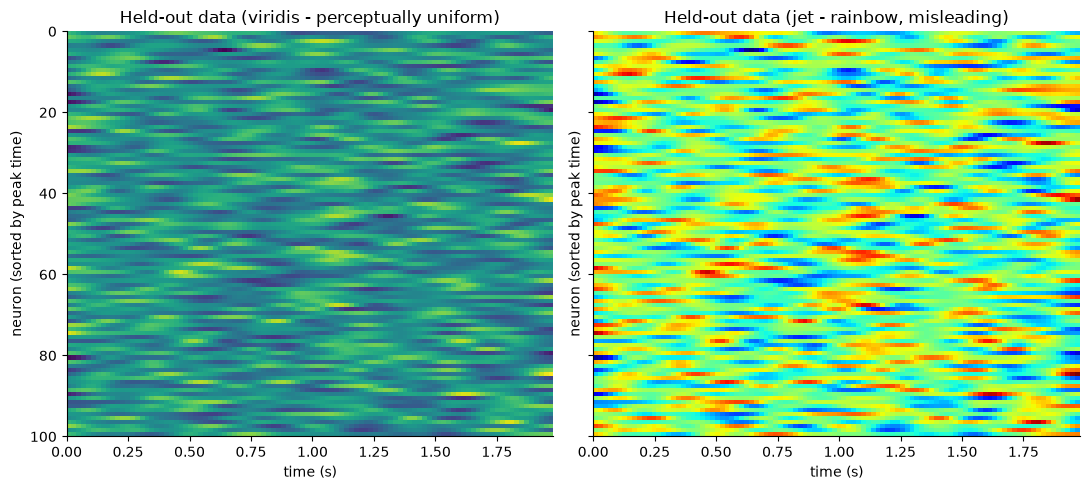

In [7]:
# ── Aside: the colormap oversells it ──────────────────────────────────────
# Jet (rainbow) adds sharp, non-uniform color transitions that the eye reads
# as edges and bands. The cross-validated (structureless) data under jet
# looks far crisper than it actually is.
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
show_seq(axes[0], test[order_train], time, cmap='viridis',
         title='Held-out data (viridis - perceptually uniform)')
show_seq(axes[1], test[order_train], time, cmap='jet',
         title='Held-out data (jet - rainbow, misleading)')
for ax in axes:
    ax.set_ylabel('neuron (sorted by peak time)')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #f0b429; padding: 1px; padding-left: 10px; background: #FFF9C4;  max-width: 90%; overflow-x: auto; color: #000000;">

## Key takeaways

The data are pure noise - there is no sequence. The diagonal is manufactured
by the sort.

- **Sorting neurons by a feature of the data and displaying that same data is
  circular.** Peak-sorting guarantees a diagonal even in pure noise - the picture
  is arranged by construction, not discovered.
- **Cross-validate sorted plots.** Choose the sort order on one set of trials and
  display an independent set. A real sequence survives; an artifact collapses.
  This applies to any sorted visualization: Rastermap, latency ranking, weight
  ranking, cluster membership.
- **Check that the sorting feature is reproducible.** A neuron's peak time should
  be consistent across independent data. A near-zero split-half correlation means
  the "preferred time" is noise.
- **Mind the colormap.** Rainbow maps like jet manufacture apparent edges and
  bands that are not in the data. Use perceptually uniform maps (viridis, magma)
  so what you see reflects what is actually there.

</div>
